# The Jacobian: From Partial Derivatives to Vector Fields

## Learning Objectives
By the end of this notebook, you will understand:
- What the **Jacobian** is and why it's important
- How to calculate the Jacobian of a function with multiple variables
- The geometric interpretation of the Jacobian as a **gradient vector**
- How Jacobians point in the direction of **steepest ascent**
- Why Jacobians are crucial for **optimization** and **machine learning**

---

## 1. What is the Jacobian?

The **Jacobian** brings together ideas from **partial derivatives** and **linear algebra** to create something incredibly powerful for optimization and machine learning.

### Definition
For a function of many variables $f(x_1, x_2, x_3, \ldots, x_n)$, the **Jacobian** is:

$$J = \begin{bmatrix} \frac{\partial f}{\partial x_1} & \frac{\partial f}{\partial x_2} & \frac{\partial f}{\partial x_3} & \cdots & \frac{\partial f}{\partial x_n} \end{bmatrix}$$

**Key Points:**
- It's a **row vector** of all partial derivatives
- Each entry tells us how the function changes with respect to that variable
- It points in the direction of **steepest increase** of the function
- The **magnitude** tells us how steep that direction is

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import sympy as sp
import seaborn as sns
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Configure matplotlib for better display
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# Define a custom arrow class for 3D plots
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        FancyArrowPatch.__init__(self, (0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))
        return np.min(zs)

print("🎯 Ready to explore the Jacobian!")
print("📚 We'll start simple and build up to beautiful visualizations!")

🎯 Ready to explore the Jacobian!
📚 We'll start simple and build up to beautiful visualizations!


## 2. A Simple Example: Building Your First Jacobian

Let's start with the example from the transcript to see how straightforward calculating a Jacobian can be.

### The Function
$$f(x, y, z) = x^2y + 3z$$

This function combines:
- A **quadratic term** in $x$: $x^2y$
- A **linear term** in $z$: $3z$
- **Three variables**: $x$, $y$, and $z$

### Step-by-Step Jacobian Calculation

To build the Jacobian, we find each partial derivative:

1. **$\frac{\partial f}{\partial x}$**: Treat $y$ and $z$ as constants
   - $\frac{\partial}{\partial x}[x^2y + 3z] = 2xy + 0 = 2xy$

2. **$\frac{\partial f}{\partial y}$**: Treat $x$ and $z$ as constants  
   - $\frac{\partial}{\partial y}[x^2y + 3z] = x^2 + 0 = x^2$

3. **$\frac{\partial f}{\partial z}$**: Treat $x$ and $y$ as constants
   - $\frac{\partial}{\partial z}[x^2y + 3z] = 0 + 3 = 3$

### The Jacobian Vector
$$J(x,y,z) = \begin{bmatrix} 2xy & x^2 & 3 \end{bmatrix}$$

SIMPLE JACOBIAN EXAMPLE
Function: f(x,y,z) = x²y + 3z

Step-by-step calculation:
-------------------------
∂f/∂x = ∂/∂x[x²y + 3z] = 2*x*y
∂f/∂y = ∂/∂y[x²y + 3z] = x**2
∂f/∂z = ∂/∂z[x²y + 3z] = 3

Jacobian: J(x,y,z) = [2*x*y, x**2, 3]

Jacobian at specific points:
------------------------------
Point ( 0,  0, 0) → J = [0, 0, 3] → f = 0, |J| = 3.00
Point ( 1,  1, 1) → J = [2, 1, 3] → f = 4, |J| = 3.74
Point ( 2, -1, 0) → J = [-4, 4, 3] → f = -4, |J| = 6.40
Point (-1,  2, 3) → J = [-4, 1, 3] → f = 11, |J| = 5.10

🔍 Key Observations:
• At (0,0,0): J = [0, 0, 3] - points purely in z-direction
• The z-component is always 3 (constant!)
• Larger |J| means steeper slope in that direction
• The Jacobian tells us which way is 'uphill'


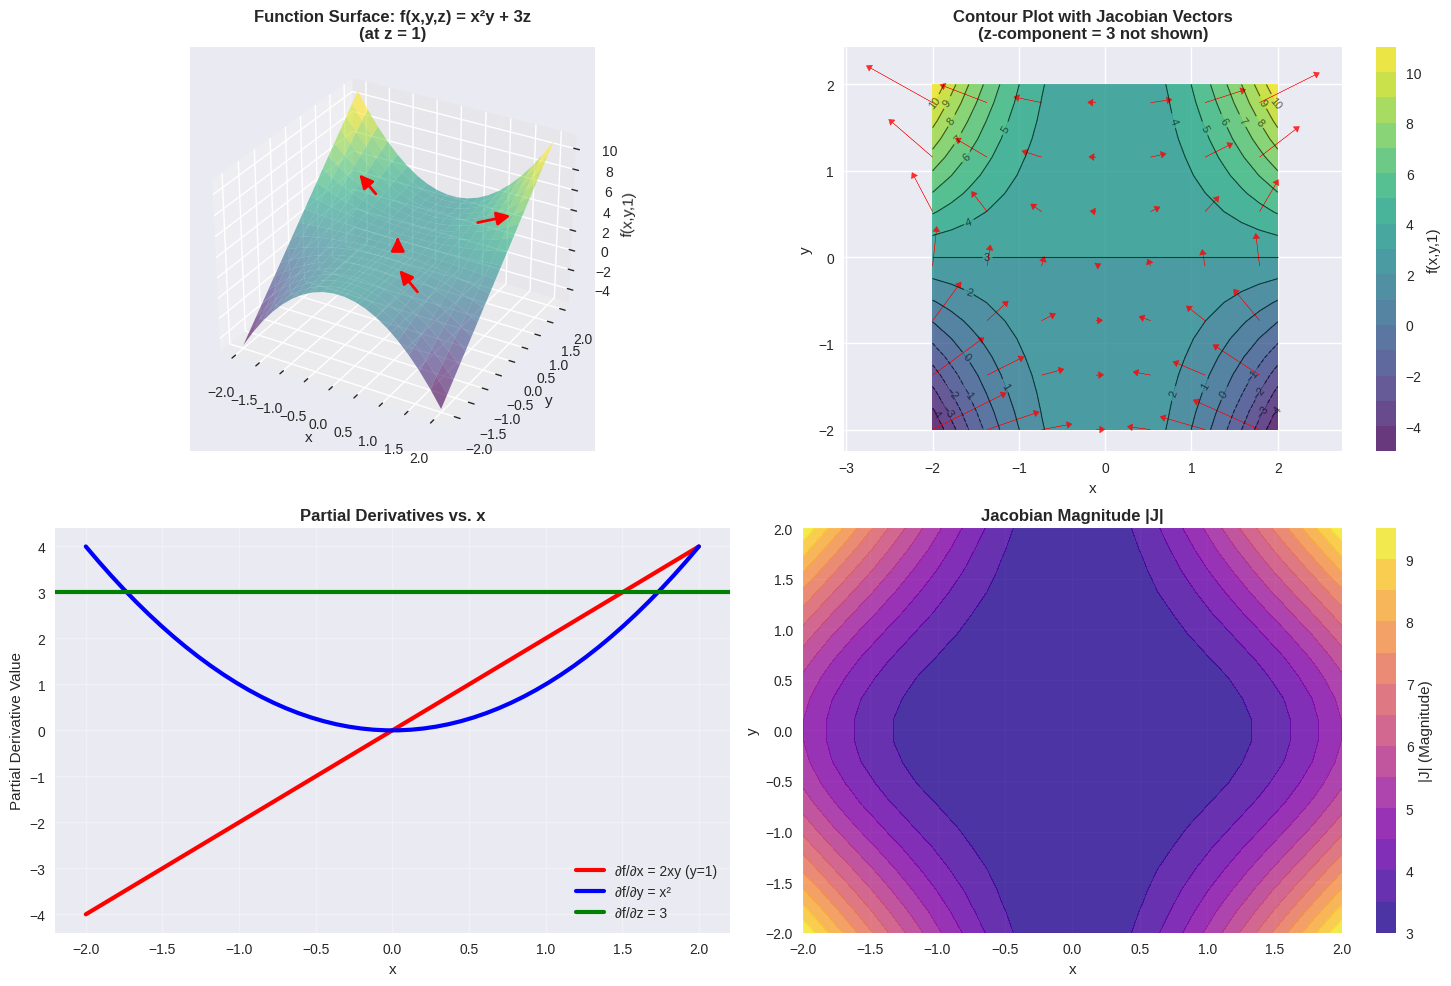

In [5]:
# Calculate the Jacobian for the simple example
print("SIMPLE JACOBIAN EXAMPLE")
print("=" * 40)
print("Function: f(x,y,z) = x²y + 3z")
print()

# Define symbols and function
x, y, z = sp.symbols('x y z', real=True)
f = x**2 * y + 3*z

print("Step-by-step calculation:")
print("-" * 25)

# Calculate partial derivatives
df_dx = sp.diff(f, x)
df_dy = sp.diff(f, y)
df_dz = sp.diff(f, z)

print(f"∂f/∂x = ∂/∂x[x²y + 3z] = {df_dx}")
print(f"∂f/∂y = ∂/∂y[x²y + 3z] = {df_dy}")
print(f"∂f/∂z = ∂/∂z[x²y + 3z] = {df_dz}")
print()

print(f"Jacobian: J(x,y,z) = [{df_dx}, {df_dy}, {df_dz}]")
print()

# Evaluate at specific points
points = [(0, 0, 0), (1, 1, 1), (2, -1, 0), (-1, 2, 3)]

print("Jacobian at specific points:")
print("-" * 30)

for point in points:
    x_val, y_val, z_val = point
    
    # Substitute values
    j_x = df_dx.subs([(x, x_val), (y, y_val), (z, z_val)])
    j_y = df_dy.subs([(x, x_val), (y, y_val), (z, z_val)])
    j_z = df_dz.subs([(x, x_val), (y, y_val), (z, z_val)])
    
    # Calculate function value
    f_val = f.subs([(x, x_val), (y, y_val), (z, z_val)])
    
    # Calculate magnitude
    magnitude = np.sqrt(float(j_x**2 + j_y**2 + j_z**2))
    
    print(f"Point ({x_val:2}, {y_val:2}, {z_val}) → J = [{j_x}, {j_y}, {j_z}] → f = {f_val}, |J| = {magnitude:.2f}")

print()
print("🔍 Key Observations:")
print("• At (0,0,0): J = [0, 0, 3] - points purely in z-direction")
print("• The z-component is always 3 (constant!)")
print("• Larger |J| means steeper slope in that direction")
print("• The Jacobian tells us which way is 'uphill'")

# Visualize the function and Jacobian vectors
fig = plt.figure(figsize=(15, 10))

# Create a 3D surface plot
ax1 = fig.add_subplot(2, 2, 1, projection='3d')

# Create meshgrid for visualization
x_vals = np.linspace(-2, 2, 20)
y_vals = np.linspace(-2, 2, 20)
X, Y = np.meshgrid(x_vals, y_vals)
Z_val = 1  # Fixed z value for surface

# Calculate function values
F_vals = X**2 * Y + 3*Z_val

# Plot surface
surf = ax1.plot_surface(X, Y, F_vals, alpha=0.6, cmap='viridis')
ax1.set_xlabel('x')
ax1.set_ylabel('y')  
ax1.set_zlabel('f(x,y,1)')
ax1.set_title('Function Surface: f(x,y,z) = x²y + 3z\n(at z = 1)', fontweight='bold')

# Add some Jacobian vectors
sample_points = [(0, 0), (1, 1), (-1, 1), (1, -1)]
for point in sample_points:
    x_p, y_p = point
    z_p = 1
    f_p = x_p**2 * y_p + 3*z_p
    
    # Calculate Jacobian at this point
    j_x = 2*x_p*y_p
    j_y = x_p**2
    j_z = 3
    
    # Scale for visibility
    scale = 0.3
    arrow = Arrow3D([x_p, x_p + scale*j_x], 
                   [y_p, y_p + scale*j_y],
                   [f_p, f_p + scale*j_z], 
                   mutation_scale=20, lw=2, arrowstyle="-|>", color="red")
    ax1.add_artist(arrow)

# Plot function contours
ax2 = fig.add_subplot(2, 2, 2)
contour = ax2.contour(X, Y, F_vals, levels=15, colors='black', alpha=0.6, linewidths=0.8)
ax2.clabel(contour, inline=True, fontsize=8)
contourf = ax2.contourf(X, Y, F_vals, levels=15, cmap='viridis', alpha=0.8)
plt.colorbar(contourf, ax=ax2, label='f(x,y,1)')

# Add Jacobian vectors as arrows
for i in range(0, len(x_vals), 3):
    for j in range(0, len(y_vals), 3):
        x_p, y_p = X[j,i], Y[j,i]
        j_x = 2*x_p*y_p
        j_y = x_p**2
        
        # Scale arrows
        scale = 0.1
        ax2.arrow(x_p, y_p, scale*j_x, scale*j_y, 
                 head_width=0.08, head_length=0.06, fc='red', ec='red', alpha=0.8)

ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Contour Plot with Jacobian Vectors\n(z-component = 3 not shown)', fontweight='bold')
ax2.set_aspect('equal')

# Individual component analysis
ax3 = fig.add_subplot(2, 2, 3)
x_line = np.linspace(-2, 2, 50)
y_fixed = 1
ax3.plot(x_line, 2*x_line*y_fixed, 'r-', linewidth=3, label=f'∂f/∂x = 2xy (y={y_fixed})')
ax3.plot(x_line, x_line**2, 'b-', linewidth=3, label='∂f/∂y = x²')
ax3.axhline(y=3, color='g', linewidth=3, label='∂f/∂z = 3')
ax3.set_xlabel('x')
ax3.set_ylabel('Partial Derivative Value')
ax3.set_title('Partial Derivatives vs. x', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Magnitude analysis
ax4 = fig.add_subplot(2, 2, 4)
magnitude_vals = np.sqrt((2*X*Y)**2 + (X**2)**2 + 3**2)
contourf2 = ax4.contourf(X, Y, magnitude_vals, levels=15, cmap='plasma', alpha=0.8)
plt.colorbar(contourf2, ax=ax4, label='|J| (Magnitude)')
ax4.set_xlabel('x')
ax4.set_ylabel('y')
ax4.set_title('Jacobian Magnitude |J|', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Geometric Interpretation: The Jacobian as a Compass

The Jacobian is much more than just a collection of partial derivatives—it's a **geometric compass** that tells us:

### 🧭 Direction of Steepest Ascent
- The Jacobian vector points in the direction where the function increases **most rapidly**
- Think of it as pointing "uphill" on the function's surface
- If you want to **maximize** the function, follow the Jacobian direction
- If you want to **minimize** the function, go in the **opposite** direction

### 📏 Magnitude = Steepness
- The **magnitude** $|J|$ tells us how steep the function is at that point
- Large magnitude = steep slope = function changes rapidly
- Small magnitude = gentle slope = function changes slowly
- Zero magnitude = flat region = local extremum (maximum, minimum, or saddle point)

### 🎯 Why This Matters for Machine Learning
- **Gradient Descent**: ML algorithms use the negative Jacobian to find function minima
- **Neural Networks**: Backpropagation computes Jacobians to update weights
- **Optimization**: Any optimization problem relies on following gradients efficiently

### Mathematical Relationship
For a point $(x_0, y_0, z_0)$, if we move a small distance $\Delta \mathbf{r} = [\Delta x, \Delta y, \Delta z]$:

$$\Delta f \approx J(x_0, y_0, z_0) \cdot \Delta \mathbf{r}$$

This tells us approximately how much the function will change!

## 4. A Beautiful 2D Example: Complex Function Visualization

Now let's explore a more complex and visually stunning example. While the transcript mentions "a particularly complicated but rather attractive function," let's create our own beautiful example that demonstrates the same principles.

### Our Complex Function
We'll use a function that creates interesting patterns:
$$f(x, y) = \sin(\sqrt{x^2 + y^2}) \cdot e^{-0.1(x^2 + y^2)} + 0.5 \cos(3 \arctan2(y, x)) \cdot e^{-0.05(x^2 + y^2)}$$

This function combines:
- **Radial waves**: $\sin(\sqrt{x^2 + y^2})$ creates circular wave patterns
- **Exponential decay**: $e^{-0.1(x^2 + y^2)}$ makes the function decay away from origin
- **Angular patterns**: $\cos(3 \arctan2(y, x))$ creates threefold symmetry
- **Multiple scales**: Different decay rates create complex interactions

### Why This Function is Perfect for Learning
1. **Visual Appeal**: Creates beautiful, interpretable patterns
2. **Multiple Features**: Has peaks, valleys, ridges, and flat regions
3. **Varied Gradients**: Shows regions of different steepness
4. **Real-world Relevance**: Similar to functions in physics, signal processing, and ML

Let's calculate its Jacobian and see what it tells us!

In [ ]:
# Create a beautiful 2D function and visualize its Jacobian
def complex_function(x, y):
    """A beautiful complex function for demonstration"""
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    
    # Radial component with exponential decay
    radial = np.sin(2*r) * np.exp(-0.1*r**2)
    
    # Angular component with threefold symmetry
    angular = 0.5 * np.cos(3*theta) * np.exp(-0.05*r**2)
    
    return radial + angular

def complex_function_gradient(x, y):
    """Calculate the gradient (Jacobian) numerically"""
    h = 1e-8
    
    # Partial derivatives using finite differences
    df_dx = (complex_function(x + h, y) - complex_function(x - h, y)) / (2*h)
    df_dy = (complex_function(x, y + h) - complex_function(x, y - h)) / (2*h)
    
    return df_dx, df_dy

# Create coordinate arrays
x_range = np.linspace(-8, 8, 100)
y_range = np.linspace(-8, 8, 100)
X, Y = np.meshgrid(x_range, y_range)

# Calculate function values
Z = complex_function(X, Y)

# Calculate gradients
DZ_DX, DZ_DY = complex_function_gradient(X, Y)

print("🎨 BEAUTIFUL 2D FUNCTION ANALYSIS")
print("=" * 50)
print("Function: f(x,y) = sin(2r)·e^(-0.1r²) + 0.5·cos(3θ)·e^(-0.05r²)")
print("where r = √(x² + y²) and θ = arctan2(y,x)")
print()

# Create the visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# 1. 3D Surface Plot
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, linewidth=0, antialiased=True)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x,y)')
ax1.set_title('3D Surface: Our Beautiful Function', fontweight='bold', fontsize=12)
ax1.view_init(elev=45, azim=45)

# 2. Contour Plot with Color
ax2 = axes[0, 1]
contourf = ax2.contourf(X, Y, Z, levels=20, cmap='viridis', alpha=0.8)
contour_lines = ax2.contour(X, Y, Z, levels=20, colors='black', alpha=0.4, linewidths=0.5)
ax2.clabel(contour_lines, inline=True, fontsize=6)
plt.colorbar(contourf, ax=ax2, label='f(x,y)')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Contour Plot: Function Values', fontweight='bold')
ax2.set_aspect('equal')

# 3. Jacobian Vector Field
ax3 = axes[1, 0]
# Subsample for cleaner vector field
step = 8
X_sub = X[::step, ::step]
Y_sub = Y[::step, ::step]
DX_sub = DZ_DX[::step, ::step]  
DY_sub = DZ_DY[::step, ::step]

# Plot contours as background
contourf3 = ax3.contourf(X, Y, Z, levels=20, cmap='viridis', alpha=0.6)
contour3 = ax3.contour(X, Y, Z, levels=20, colors='black', alpha=0.3, linewidths=0.5)

# Plot vector field
quiver = ax3.quiver(X_sub, Y_sub, DX_sub, DY_sub, 
                   scale=20, scale_units='xy', angles='xy', 
                   color='red', alpha=0.8, width=0.003)

ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_title('Jacobian Vector Field\n(Red arrows = gradient direction)', fontweight='bold')
ax3.set_aspect('equal')

# 4. Gradient Magnitude
ax4 = axes[1, 1]
gradient_magnitude = np.sqrt(DZ_DX**2 + DZ_DY**2)
contourf4 = ax4.contourf(X, Y, gradient_magnitude, levels=20, cmap='plasma', alpha=0.8)
plt.colorbar(contourf4, ax=ax4, label='|∇f| (Gradient Magnitude)')
ax4.set_xlabel('x')
ax4.set_ylabel('y')
ax4.set_title('Gradient Magnitude\n(Bright = steep, Dark = flat)', fontweight='bold')
ax4.set_aspect('equal')

plt.tight_layout()
plt.show()

# Analyze specific points like in the transcript
special_points = [
    (-3, 2, "A - Near a ridge"),
    (0, 0, "B - At the center"),
    (4, -1, "C - In a valley"),
    (-1, -4, "D - On a slope")
]

print("\n🔍 ANALYSIS OF SPECIFIC POINTS:")
print("=" * 40)

for i, (x_p, y_p, description) in enumerate(special_points):
    # Calculate function value and gradient at this point
    f_val = complex_function(x_p, y_p)
    grad_x, grad_y = complex_function_gradient(x_p, y_p)
    magnitude = np.sqrt(grad_x**2 + grad_y**2)
    
    print(f"Point {chr(65+i)} at ({x_p:2}, {y_p:2}) - {description}")
    print(f"  Function value: f = {f_val:.3f}")
    print(f"  Jacobian: J = [{grad_x:6.3f}, {grad_y:6.3f}]")
    print(f"  Magnitude: |J| = {magnitude:.3f}")
    print(f"  Direction: {np.degrees(np.arctan2(grad_y, grad_x)):6.1f}° from +x axis")
    print()

print("💡 INTERPRETATION GUIDE:")
print("• Large |J| = steep slope = function changes rapidly")
print("• Small |J| = gentle slope = function changes slowly") 
print("• Jacobian arrows point UPHILL (toward higher function values)")
print("• In contour plots, arrows point perpendicular to contour lines")
print("• Tightly packed contours = large gradients = long arrows")

In [ ]:
# Interactive exploration: Relationship between contours and gradients
print("🔬 EXPLORING THE CONTOUR-GRADIENT RELATIONSHIP")
print("=" * 55)

# Create a simpler function for clearer demonstration
def simple_peaks(x, y):
    """A function with clear peaks and valleys"""
    return (1 - x**2 - y**2) * np.exp(-0.5*(x**2 + y**2)) + 0.5 * np.exp(-0.5*((x-2)**2 + (y-1)**2))

def simple_peaks_gradient(x, y):
    """Analytical gradient of the simple_peaks function"""
    # First peak contribution
    exp1 = np.exp(-0.5*(x**2 + y**2))
    term1 = (1 - x**2 - y**2)
    
    df_dx_1 = exp1 * (-2*x) + term1 * exp1 * (-x)
    df_dy_1 = exp1 * (-2*y) + term1 * exp1 * (-y)
    
    # Second peak contribution  
    exp2 = np.exp(-0.5*((x-2)**2 + (y-1)**2))
    df_dx_2 = 0.5 * exp2 * (-(x-2))
    df_dy_2 = 0.5 * exp2 * (-(y-1))
    
    return df_dx_1 + df_dx_2, df_dy_1 + df_dy_2

# Create finer grid for this analysis
x_fine = np.linspace(-3, 4, 80)
y_fine = np.linspace(-2, 3, 60)
X_fine, Y_fine = np.meshgrid(x_fine, y_fine)
Z_fine = simple_peaks(X_fine, Y_fine)
DX_fine, DY_fine = simple_peaks_gradient(X_fine, Y_fine)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Function with contours and selected points
ax1 = axes[0, 0]
contour_filled = ax1.contourf(X_fine, Y_fine, Z_fine, levels=15, cmap='terrain', alpha=0.8)
contour_lines = ax1.contour(X_fine, Y_fine, Z_fine, levels=15, colors='black', alpha=0.6, linewidths=1)
ax1.clabel(contour_lines, inline=True, fontsize=8)

# Mark special points for analysis
analysis_points = [
    (-1, 0, 'Valley'),
    (0, 0, 'Saddle'),  
    (2, 1, 'Peak'),
    (1, -1, 'Slope')
]

colors = ['red', 'blue', 'green', 'orange']
for i, (x_p, y_p, label) in enumerate(analysis_points):
    ax1.plot(x_p, y_p, 'o', color=colors[i], markersize=10, markeredgecolor='white', markeredgewidth=2)
    ax1.annotate(f'{label}\n({x_p}, {y_p})', (x_p, y_p), xytext=(10, 10), 
                textcoords='offset points', fontsize=9, color=colors[i], fontweight='bold')

ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Function Landscape with Key Points', fontweight='bold')
ax1.set_aspect('equal')
plt.colorbar(contour_filled, ax=ax1, label='f(x,y)')

# 2. Gradient vectors at selected points
ax2 = axes[0, 1]
ax2.contour(X_fine, Y_fine, Z_fine, levels=15, colors='gray', alpha=0.4, linewidths=0.8)

# Show gradients at our analysis points
for i, (x_p, y_p, label) in enumerate(analysis_points):
    grad_x, grad_y = simple_peaks_gradient(x_p, y_p)
    magnitude = np.sqrt(grad_x**2 + grad_y**2)
    
    # Scale arrow for visibility
    scale = 2.0
    ax2.arrow(x_p, y_p, scale*grad_x, scale*grad_y, 
             head_width=0.15, head_length=0.1, fc=colors[i], ec=colors[i], linewidth=2)
    
    # Add magnitude text
    ax2.text(x_p + scale*grad_x + 0.3, y_p + scale*grad_y, 
            f'|∇f| = {magnitude:.2f}', fontsize=9, color=colors[i], fontweight='bold')

ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Gradient Vectors at Key Points\n(Length ∝ steepness)', fontweight='bold')
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)

# 3. Full vector field (subsampled)
ax3 = axes[1, 0]
step = 4
X_sub = X_fine[::step, ::step]
Y_sub = Y_fine[::step, ::step]
DX_sub = DX_fine[::step, ::step]  
DY_sub = DY_fine[::step, ::step]

# Background contours
ax3.contourf(X_fine, Y_fine, Z_fine, levels=15, cmap='terrain', alpha=0.6)
ax3.contour(X_fine, Y_fine, Z_fine, levels=15, colors='black', alpha=0.4, linewidths=0.5)

# Vector field
ax3.quiver(X_sub, Y_sub, DX_sub, DY_sub, 
          scale=15, scale_units='xy', angles='xy', 
          color='red', alpha=0.8, width=0.004)

ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_title('Complete Gradient Vector Field\n(Arrows always ⊥ to contours)', fontweight='bold')
ax3.set_aspect('equal')

# 4. Magnitude heatmap
ax4 = axes[1, 1]
magnitude_field = np.sqrt(DX_fine**2 + DY_fine**2)
heatmap = ax4.contourf(X_fine, Y_fine, magnitude_field, levels=20, cmap='hot', alpha=0.8)
ax4.contour(X_fine, Y_fine, Z_fine, levels=8, colors='white', alpha=0.6, linewidths=1)
plt.colorbar(heatmap, ax=ax4, label='|∇f| (Steepness)')

ax4.set_xlabel('x')
ax4.set_ylabel('y')
ax4.set_title('Gradient Magnitude\n(Hot = steep, Cool = flat)', fontweight='bold')
ax4.set_aspect('equal')

plt.tight_layout()
plt.show()

# Detailed analysis of the relationship
print("\n📊 DETAILED ANALYSIS OF KEY POINTS:")
print("=" * 45)

for i, (x_p, y_p, label) in enumerate(analysis_points):
    f_val = simple_peaks(x_p, y_p)
    grad_x, grad_y = simple_peaks_gradient(x_p, y_p)
    magnitude = np.sqrt(grad_x**2 + grad_y**2)
    direction = np.degrees(np.arctan2(grad_y, grad_x))
    
    print(f"{label} at ({x_p}, {y_p}):")
    print(f"  📈 Function value: {f_val:.3f}")
    print(f"  🧭 Gradient: [{grad_x:6.3f}, {grad_y:6.3f}]")
    print(f"  📏 Magnitude: {magnitude:.3f}")
    print(f"  🎯 Direction: {direction:.1f}° from +x axis")
    
    if magnitude < 0.1:
        print(f"  💡 This is near a critical point (flat region)!")
    elif magnitude > 1.0:
        print(f"  💡 This is a steep region - rapid change!")
    else:
        print(f"  💡 This is a moderate slope region.")
    print()

print("🎯 KEY INSIGHTS:")
print("• Gradients are ALWAYS perpendicular to contour lines")
print("• Large gradients occur where contour lines are tightly packed")
print("• At peaks, valleys, and saddle points, gradients are small/zero")
print("• The gradient always points toward increasing function values")
print("• This is why gradient descent works: follow -∇f to find minima!")

## 5. Applications in Machine Learning and Optimization

Now that we understand what Jacobians are and how they work geometrically, let's see why they're absolutely crucial in machine learning and optimization.

### 🎯 Gradient Descent: The Heart of Machine Learning

**Gradient Descent** is the fundamental algorithm that trains most machine learning models. Here's how it works:

1. **Start** at some point in the parameter space
2. **Calculate** the Jacobian (gradient) of the loss function
3. **Move** in the **opposite** direction of the gradient (downhill)
4. **Repeat** until you reach a minimum

$$\theta_{new} = \theta_{old} - \alpha \nabla f(\theta_{old})$$

Where:
- $\theta$ = parameters (weights, biases, etc.)
- $\alpha$ = learning rate (step size)
- $\nabla f$ = Jacobian/gradient of the loss function
- We use **negative** gradient because we want to **minimize** loss

### 🧠 Neural Networks: Backpropagation

**Backpropagation** is essentially the chain rule applied to compute Jacobians efficiently:
- Each layer computes partial derivatives
- These are "propagated backward" through the network
- The final result is the Jacobian of the loss w.r.t. all parameters

### 🔍 Optimization in High Dimensions

The transcript mentions "numerical methods in hundreds of dimensions." This is exactly what happens in deep learning:
- **GPT models**: Millions to billions of parameters
- **Image recognition**: Thousands to millions of parameters  
- **Recommendation systems**: Millions of parameters

The Jacobian tells us how to adjust ALL these parameters simultaneously!

### 🗺️ Why the "Contour Map" Analogy is Perfect

Think of the loss function as a mountainous landscape:
- **Peaks** = bad parameter settings (high loss)
- **Valleys** = good parameter settings (low loss)
- **Jacobian** = compass pointing uphill
- **Negative Jacobian** = compass pointing downhill (what we want!)

Just like a hiker uses topographic maps to find the lowest valley, ML algorithms use Jacobians to find the best parameters.

In [ ]:
# Simulate gradient descent to show Jacobians in action
print("🚀 GRADIENT DESCENT SIMULATION")
print("=" * 40)
print("Watch how the algorithm uses Jacobians to find the minimum!")
print()

def quadratic_bowl(x, y):
    """A simple quadratic function with a clear minimum"""
    return 0.5 * (x**2 + 2*y**2) + 0.1*x*y + 0.5

def quadratic_bowl_gradient(x, y):
    """Gradient of the quadratic bowl"""
    df_dx = x + 0.1*y
    df_dy = 4*y + 0.1*x
    return df_dx, df_dy

def gradient_descent_step(x, y, learning_rate=0.1):
    """Take one step of gradient descent"""
    grad_x, grad_y = quadratic_bowl_gradient(x, y)
    
    # Move in OPPOSITE direction of gradient (downhill)
    x_new = x - learning_rate * grad_x
    y_new = y - learning_rate * grad_y
    
    return x_new, y_new

# Run gradient descent from multiple starting points
starting_points = [(3, 2), (-2, 1.5), (1, -2), (-1, -1)]
learning_rate = 0.2
max_iterations = 50

# Set up the visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Create background landscape
x_bg = np.linspace(-4, 4, 100)
y_bg = np.linspace(-3, 3, 100)
X_bg, Y_bg = np.meshgrid(x_bg, y_bg)
Z_bg = quadratic_bowl(X_bg, Y_bg)

# Plot 1: 3D surface with gradient descent paths
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
surf = ax1.plot_surface(X_bg, Y_bg, Z_bg, alpha=0.6, cmap='viridis')
ax1.set_xlabel('x (Parameter 1)')
ax1.set_ylabel('y (Parameter 2)')
ax1.set_zlabel('Loss Function')
ax1.set_title('3D Loss Surface with Optimization Paths', fontweight='bold')

# Plot 2: Contour with all paths
ax2 = axes[0, 1]
contour = ax2.contour(X_bg, Y_bg, Z_bg, levels=20, colors='gray', alpha=0.6)
ax2.clabel(contour, inline=True, fontsize=8)
contourf = ax2.contourf(X_bg, Y_bg, Z_bg, levels=20, cmap='viridis', alpha=0.4)

colors = ['red', 'blue', 'green', 'orange']
all_paths = []

for i, (start_x, start_y) in enumerate(starting_points):
    # Run gradient descent
    path_x = [start_x]
    path_y = [start_y]
    path_z = [quadratic_bowl(start_x, start_y)]
    
    x, y = start_x, start_y
    
    for iteration in range(max_iterations):
        x, y = gradient_descent_step(x, y, learning_rate)
        path_x.append(x)
        path_y.append(y)
        path_z.append(quadratic_bowl(x, y))
        
        # Stop if we're close enough to the minimum
        if abs(x) < 0.01 and abs(y) < 0.01:
            break
    
    all_paths.append((path_x, path_y, path_z, colors[i]))
    
    # Plot 3D path
    ax1.plot(path_x, path_y, path_z, color=colors[i], linewidth=3, alpha=0.8)
    ax1.scatter(start_x, start_y, quadratic_bowl(start_x, start_y), 
               color=colors[i], s=100, marker='o', label=f'Start {i+1}')
    ax1.scatter(path_x[-1], path_y[-1], path_z[-1], 
               color=colors[i], s=150, marker='*')
    
    # Plot 2D path
    ax2.plot(path_x, path_y, color=colors[i], linewidth=2, alpha=0.8, label=f'Path {i+1}')
    ax2.scatter(start_x, start_y, color=colors[i], s=100, marker='o', zorder=5)
    ax2.scatter(path_x[-1], path_y[-1], color=colors[i], s=150, marker='*', zorder=5)

# Mark the true minimum
true_min_x, true_min_y = 0, 0
ax1.scatter(true_min_x, true_min_y, quadratic_bowl(true_min_x, true_min_y), 
           color='black', s=200, marker='X', label='True Minimum')
ax2.scatter(true_min_x, true_min_y, color='black', s=200, marker='X', zorder=6, label='True Minimum')

ax1.legend()
ax2.set_xlabel('x (Parameter 1)')
ax2.set_ylabel('y (Parameter 2)')
ax2.set_title('Gradient Descent Paths (Top View)', fontweight='bold')
ax2.legend()
ax2.set_aspect('equal')

# Plot 3: Show gradients at specific points
ax3 = axes[1, 0] 
ax3.contour(X_bg, Y_bg, Z_bg, levels=15, colors='gray', alpha=0.5)

# Show gradient vectors at various points
sample_points = [(-2, 1), (2, -1), (-1, -1.5), (1, 1)]
for x_p, y_p in sample_points:
    grad_x, grad_y = quadratic_bowl_gradient(x_p, y_p)
    
    # Show gradient (uphill direction)
    ax3.arrow(x_p, y_p, 0.3*grad_x, 0.3*grad_y, 
             head_width=0.1, head_length=0.08, fc='red', ec='red', alpha=0.7, linewidth=2)
    
    # Show negative gradient (downhill direction - what GD follows)
    ax3.arrow(x_p, y_p, -0.3*grad_x, -0.3*grad_y, 
             head_width=0.1, head_length=0.08, fc='blue', ec='blue', alpha=0.7, linewidth=2)

ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_title('Gradient Vectors\nRed = ∇f (uphill), Blue = -∇f (downhill)', fontweight='bold')
ax3.set_aspect('equal')

# Plot 4: Convergence analysis
ax4 = axes[1, 1]
for i, (path_x, path_y, path_z, color) in enumerate(all_paths):
    iterations = range(len(path_z))
    ax4.semilogy(iterations, path_z, color=color, linewidth=2, 
                marker='o', markersize=4, label=f'Start {i+1}')

ax4.set_xlabel('Iteration')
ax4.set_ylabel('Loss (log scale)')
ax4.set_title('Convergence: Loss vs Iterations', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analysis of the results
print("📊 GRADIENT DESCENT ANALYSIS:")
print("=" * 35)

for i, (path_x, path_y, path_z, color) in enumerate(all_paths):
    start_loss = path_z[0]
    final_loss = path_z[-1]
    improvement = start_loss - final_loss
    iterations = len(path_z) - 1
    
    print(f"Path {i+1} (starting at ({starting_points[i][0]}, {starting_points[i][1]})):")
    print(f"  🎯 Initial loss: {start_loss:.4f}")
    print(f"  🏁 Final loss: {final_loss:.4f}")
    print(f"  📈 Improvement: {improvement:.4f}")
    print(f"  🔄 Iterations: {iterations}")
    print(f"  📍 Final point: ({path_x[-1]:.3f}, {path_y[-1]:.3f})")
    print()

print("🎯 KEY OBSERVATIONS:")
print("• All paths converge to the same minimum (0, 0)")
print("• Paths always follow the negative gradient direction")
print("• Steeper regions = larger gradients = bigger steps")
print("• Flatter regions = smaller gradients = smaller steps")
print("• Learning rate controls step size (too big = overshooting)")
print("• This is exactly how neural networks learn!")

print("\n🧠 CONNECTION TO MACHINE LEARNING:")
print("• Replace (x,y) with neural network weights/biases")
print("• Replace loss function with prediction error")
print("• Same algorithm optimizes millions of parameters!")
print("• Jacobian/gradient tells us how to improve the model")

## 6. Practice Exercises: Master the Jacobian

Let's test your understanding with some hands-on exercises!

### Exercise 1: Calculate Jacobians
For each function, calculate the Jacobian vector:

**a)** $f(x, y) = 3x^2 + 2xy + y^3$

**b)** $g(u, v, w) = \sin(u) + \cos(v) + e^w$

**c)** $h(a, b) = a^2 e^b + \ln(a + b)$

### Exercise 2: Geometric Interpretation
For the function $f(x, y) = x^2 + 4y^2$:

**a)** Calculate the Jacobian

**b)** Find the Jacobian at points $(1, 0)$, $(0, 1)$, and $(2, 1)$

**c)** Which point has the largest gradient magnitude?

**d)** In which direction should you move from $(2, 1)$ to decrease the function most rapidly?

### Exercise 3: Gradient Descent Understanding
If you're at point $(3, 2)$ and the Jacobian is $[6, 8]$:

**a)** In which direction does the function increase most rapidly?

**b)** If using gradient descent with learning rate $\alpha = 0.1$, what's your next position?

**c)** What would happen if the learning rate was too large?

In [ ]:
# Solutions to Practice Exercises
print("📝 SOLUTIONS TO PRACTICE EXERCISES")
print("=" * 45)

# Exercise 1: Calculate Jacobians
print("EXERCISE 1: Calculate Jacobians")
print("-" * 35)

# Define symbols
x, y, u, v, w, a, b = sp.symbols('x y u v w a b', real=True, positive=True)

# Exercise 1a
print("a) f(x,y) = 3x² + 2xy + y³")
f1 = 3*x**2 + 2*x*y + y**3
df1_dx = sp.diff(f1, x)
df1_dy = sp.diff(f1, y)
print(f"   ∂f/∂x = {df1_dx}")
print(f"   ∂f/∂y = {df1_dy}")
print(f"   Jacobian: J = [{df1_dx}, {df1_dy}]")
print()

# Exercise 1b
print("b) g(u,v,w) = sin(u) + cos(v) + eʷ")
g1 = sp.sin(u) + sp.cos(v) + sp.exp(w)
dg1_du = sp.diff(g1, u)
dg1_dv = sp.diff(g1, v)
dg1_dw = sp.diff(g1, w)
print(f"   ∂g/∂u = {dg1_du}")
print(f"   ∂g/∂v = {dg1_dv}")
print(f"   ∂g/∂w = {dg1_dw}")
print(f"   Jacobian: J = [{dg1_du}, {dg1_dv}, {dg1_dw}]")
print()

# Exercise 1c
print("c) h(a,b) = a²eᵇ + ln(a + b)")
h1 = a**2 * sp.exp(b) + sp.log(a + b)
dh1_da = sp.diff(h1, a)
dh1_db = sp.diff(h1, b)
print(f"   ∂h/∂a = {dh1_da}")
print(f"   ∂h/∂b = {dh1_db}")
print(f"   Jacobian: J = [{dh1_da}, {dh1_db}]")
print()

# Exercise 2: Geometric Interpretation
print("EXERCISE 2: Geometric Interpretation")
print("-" * 40)
print("Function: f(x,y) = x² + 4y²")

f2 = x**2 + 4*y**2
df2_dx = sp.diff(f2, x)
df2_dy = sp.diff(f2, y)

print(f"a) Jacobian: J = [{df2_dx}, {df2_dy}] = [2x, 8y]")
print()

# Evaluate at specific points
points = [(1, 0), (0, 1), (2, 1)]
print("b) Jacobian at specific points:")

magnitudes = []
for point in points:
    x_val, y_val = point
    j_x = 2*x_val
    j_y = 8*y_val
    magnitude = np.sqrt(j_x**2 + j_y**2)
    magnitudes.append(magnitude)
    
    print(f"   At ({x_val}, {y_val}): J = [{j_x}, {j_y}], |J| = {magnitude:.2f}")

print()
max_idx = np.argmax(magnitudes)
print(f"c) Point with largest gradient magnitude: {points[max_idx]} with |J| = {magnitudes[max_idx]:.2f}")
print()

# Direction for steepest descent
point_2_1 = (2, 1)
j_x_2_1 = 2*2  # 4
j_y_2_1 = 8*1  # 8
print(f"d) At (2,1), gradient is [4, 8]")
print(f"   For steepest DESCENT, move in direction [-4, -8] (negative gradient)")
print(f"   Normalized: [{-4/np.sqrt(80):.3f}, {-8/np.sqrt(80):.3f}]")
print()

# Exercise 3: Gradient Descent Understanding
print("EXERCISE 3: Gradient Descent Understanding")
print("-" * 45)
print("Starting point: (3, 2), Jacobian: [6, 8], Learning rate: α = 0.1")
print()

current_pos = np.array([3, 2])
gradient = np.array([6, 8])
learning_rate = 0.1

print("a) Direction of steepest INCREASE:")
direction = gradient / np.linalg.norm(gradient)
print(f"   Gradient direction: [{gradient[0]}, {gradient[1]}]")
print(f"   Normalized: [{direction[0]:.3f}, {direction[1]:.3f}]")
print(f"   Angle: {np.degrees(np.arctan2(gradient[1], gradient[0])):.1f}° from +x axis")
print()

print("b) Next position with gradient descent:")
next_pos = current_pos - learning_rate * gradient
print(f"   Next position = (3, 2) - 0.1 × [6, 8]")
print(f"   Next position = (3, 2) - [0.6, 0.8]")
print(f"   Next position = ({next_pos[0]}, {next_pos[1]})")
print()

print("c) If learning rate is too large:")
large_lr = 2.0
large_step = current_pos - large_lr * gradient
print(f"   With α = {large_lr}: next position = ({large_step[0]}, {large_step[1]})")
print("   Problems with large learning rates:")
print("   - May overshoot the minimum")
print("   - Can cause oscillation or divergence")
print("   - Algorithm becomes unstable")
print("   - Need to balance speed vs stability")

# Visualize Exercise 2
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot the function f(x,y) = x² + 4y²
x_range = np.linspace(-3, 3, 100)
y_range = np.linspace(-2, 2, 100)
X_ex, Y_ex = np.meshgrid(x_range, y_range)
Z_ex = X_ex**2 + 4*Y_ex**2

# Left plot: Contours with gradient vectors
ax1 = axes[0]
contour = ax1.contour(X_ex, Y_ex, Z_ex, levels=15, colors='gray', alpha=0.6)
ax1.clabel(contour, inline=True, fontsize=8)
contourf = ax1.contourf(X_ex, Y_ex, Z_ex, levels=15, cmap='viridis', alpha=0.5)

# Add gradient vectors at the three points
colors = ['red', 'blue', 'green']
for i, (x_p, y_p) in enumerate(points):
    j_x = 2*x_p
    j_y = 8*y_p
    
    # Scale for visibility
    scale = 0.2
    ax1.arrow(x_p, y_p, scale*j_x, scale*j_y, 
             head_width=0.1, head_length=0.08, fc=colors[i], ec=colors[i], linewidth=2)
    ax1.plot(x_p, y_p, 'o', color=colors[i], markersize=8, markeredgecolor='white', markeredgewidth=2)
    ax1.text(x_p + 0.2, y_p + 0.1, f'({x_p},{y_p})', fontsize=10, color=colors[i], fontweight='bold')

ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Exercise 2: f(x,y) = x² + 4y²\nwith Gradient Vectors', fontweight='bold')
ax1.set_aspect('equal')
plt.colorbar(contourf, ax=ax1, label='f(x,y)')

# Right plot: Gradient descent simulation for Exercise 3
ax2 = axes[1]

# Create a simple function for visualization
def simple_func(x, y):
    return (x-1)**2 + 2*(y-0.5)**2

def simple_grad(x, y):
    return 2*(x-1), 4*(y-0.5)

x_sim = np.linspace(-1, 4, 50)
y_sim = np.linspace(-1, 3, 50)
X_sim, Y_sim = np.meshgrid(x_sim, y_sim)
Z_sim = simple_func(X_sim, Y_sim)

ax2.contour(X_sim, Y_sim, Z_sim, levels=10, colors='gray', alpha=0.6)
ax2.contourf(X_sim, Y_sim, Z_sim, levels=10, cmap='viridis', alpha=0.5)

# Simulate gradient descent from (3, 2)
start_x, start_y = 3, 2
path_x, path_y = [start_x], [start_y]

x_curr, y_curr = start_x, start_y
for i in range(10):
    grad_x, grad_y = simple_grad(x_curr, y_curr)
    x_curr = x_curr - 0.1 * grad_x
    y_curr = y_curr - 0.1 * grad_y
    path_x.append(x_curr)
    path_y.append(y_curr)

ax2.plot(path_x, path_y, 'r-', linewidth=3, alpha=0.8, label='Gradient Descent Path')
ax2.plot(path_x[0], path_y[0], 'go', markersize=10, label='Start')
ax2.plot(path_x[-1], path_y[-1], 'r*', markersize=15, label='End')
ax2.plot(1, 0.5, 'kX', markersize=12, label='True Minimum')

ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Exercise 3: Gradient Descent\nfrom (3,2) to minimum', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

print("\n🎯 KEY TAKEAWAYS FROM EXERCISES:")
print("• Jacobians are straightforward to calculate using differentiation rules")
print("• Geometric interpretation: direction and magnitude of steepest ascent") 
print("• Gradient descent uses NEGATIVE Jacobian to find minima")
print("• Learning rate controls step size - balance speed vs stability")
print("• These concepts are fundamental to ALL machine learning algorithms!")

## 7. Summary and Key Takeaways

### 🎯 What We've Mastered

1. **The Jacobian Definition**
   - A row vector of all partial derivatives
   - Points in the direction of steepest function increase
   - Magnitude indicates how steep that direction is

2. **Geometric Intuition**
   - Jacobian = compass pointing "uphill"
   - Always perpendicular to contour lines
   - Large magnitude = steep slope, small magnitude = gentle slope

3. **Calculation Skills**
   - Apply standard differentiation rules to each variable
   - Treat other variables as constants
   - Arrange results as a row vector

4. **Real-World Applications**
   - **Gradient Descent**: Follow negative Jacobian to minimize functions
   - **Neural Networks**: Backpropagation computes Jacobians efficiently
   - **Optimization**: Essential for finding best parameters in any ML model

### 🧭 The Mountain Climbing Analogy

Think of any function as a mountainous landscape:
- **Function value** = elevation/height
- **Jacobian** = compass pointing to steepest uphill direction
- **Negative Jacobian** = compass pointing to steepest downhill direction
- **Magnitude** = steepness of that direction
- **Gradient Descent** = following the downhill compass to reach valleys

### 🤖 Connection to Machine Learning

Every time a machine learning model learns, it uses Jacobians:

1. **Start** with random parameters (random point on landscape)
2. **Calculate loss** (height at current point)
3. **Compute Jacobian** (which direction is steepest downhill?)
4. **Take a step** in negative Jacobian direction
5. **Repeat** until reaching a minimum (trained model)

This happens millions of times during training, often with millions of parameters!

### 🔍 Why High Dimensions Aren't Scary

The transcript mentions "hundreds of dimensions"—but the concept remains the same:
- **2D**: Jacobian = $[∂f/∂x, ∂f/∂y]$ (2 components)
- **3D**: Jacobian = $[∂f/∂x, ∂f/∂y, ∂f/∂z]$ (3 components)  
- **1000D**: Jacobian = $[∂f/∂x_1, ∂f/∂x_2, ..., ∂f/∂x_{1000}]$ (1000 components)

Same concept, just more dimensions to keep track of!

### 🚀 What's Next?

With Jacobians mastered, you're ready for:
- **Advanced optimization algorithms** (Adam, RMSprop, etc.)
- **Deep learning** and neural network training
- **Multivariable optimization** in any field
- **Vector calculus** and divergence/curl operators

### 💡 Remember This

> *"The Jacobian is not just math—it's the fundamental tool that makes all modern AI possible. Every time ChatGPT learns something new, every time your phone recognizes your face, every time Netflix recommends a movie—Jacobians are working behind the scenes!"*

You now have the mathematical foundation to understand how AI systems actually learn and improve. That's incredibly powerful knowledge!

In [ ]:
# 🎯 Final Challenge: Create and Explore Your Own Function!
print("🚀 CREATE YOUR OWN JACOBIAN EXPLORATION")
print("=" * 50)
print("Time to become a Jacobian expert! Modify the function below and explore.")
print()

# Template function for students to modify
def custom_function(x, y):
    """
    Modify this function to explore different Jacobian behaviors!
    Try different combinations and see how they affect the gradient field.
    """
    # Current example: A function with interesting features
    return np.sin(x) * np.cos(y) + 0.1 * (x**2 + y**2)

def custom_gradient(x, y):
    """Calculate gradient numerically"""
    h = 1e-8
    df_dx = (custom_function(x + h, y) - custom_function(x - h, y)) / (2*h)
    df_dy = (custom_function(x, y + h) - custom_function(x, y - h)) / (2*h)
    return df_dx, df_dy

print("🎨 CURRENT FUNCTION:")
print("f(x,y) = sin(x)·cos(y) + 0.1·(x² + y²)")
print()
print("🔧 TRY MODIFYING THE FUNCTION TO:")
print("• A simple bowl: x² + y²")
print("• A saddle: x² - y²") 
print("• Ripples: sin(x) + sin(y)")
print("• Complex waves: sin(√(x² + y²))")
print("• Your own creation!")
print()

# Create visualization of the custom function
x_range = np.linspace(-3, 3, 60)
y_range = np.linspace(-3, 3, 60)
X_custom, Y_custom = np.meshgrid(x_range, y_range)
Z_custom = custom_function(X_custom, Y_custom)
DX_custom, DY_custom = custom_gradient(X_custom, Y_custom)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. 3D Surface
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
surf = ax1.plot_surface(X_custom, Y_custom, Z_custom, cmap='viridis', alpha=0.8)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x,y)')
ax1.set_title('Your Custom Function (3D)', fontweight='bold')

# 2. Contour with Jacobian vectors
ax2 = axes[0, 1]
contour = ax2.contour(X_custom, Y_custom, Z_custom, levels=15, colors='black', alpha=0.5)
ax2.contourf(X_custom, Y_custom, Z_custom, levels=15, cmap='viridis', alpha=0.7)

# Add gradient vectors (subsampled)
step = 6
X_sub = X_custom[::step, ::step]
Y_sub = Y_custom[::step, ::step]
DX_sub = DX_custom[::step, ::step]
DY_sub = DY_custom[::step, ::step]

ax2.quiver(X_sub, Y_sub, DX_sub, DY_sub, 
          scale=30, scale_units='xy', angles='xy', 
          color='red', alpha=0.8, width=0.003)

ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Contours + Jacobian Vectors', fontweight='bold')
ax2.set_aspect('equal')

# 3. Gradient Magnitude
ax3 = axes[1, 0]
magnitude = np.sqrt(DX_custom**2 + DY_custom**2)
mag_plot = ax3.contourf(X_custom, Y_custom, magnitude, levels=20, cmap='hot')
ax3.contour(X_custom, Y_custom, Z_custom, levels=10, colors='white', alpha=0.5)
plt.colorbar(mag_plot, ax=ax3, label='|∇f|')
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_title('Gradient Magnitude', fontweight='bold')
ax3.set_aspect('equal')

# 4. Special points analysis
ax4 = axes[1, 1]
ax4.contour(X_custom, Y_custom, Z_custom, levels=15, colors='gray', alpha=0.5)

# Find and mark interesting points
interesting_points = [(-1, 1), (0, 0), (1, -1), (2, 0)]
colors = ['red', 'blue', 'green', 'orange']

for i, (x_p, y_p) in enumerate(interesting_points):
    f_val = custom_function(x_p, y_p)
    grad_x, grad_y = custom_gradient(x_p, y_p)
    magnitude = np.sqrt(grad_x**2 + grad_y**2)
    
    # Plot point
    ax4.plot(x_p, y_p, 'o', color=colors[i], markersize=10, 
            markeredgecolor='white', markeredgewidth=2)
    
    # Plot gradient vector
    scale = 0.5
    ax4.arrow(x_p, y_p, scale*grad_x, scale*grad_y, 
             head_width=0.1, head_length=0.08, fc=colors[i], ec=colors[i], alpha=0.8)
    
    # Add label
    ax4.text(x_p + 0.3, y_p + 0.2, f'({x_p},{y_p})\n|∇f|={magnitude:.2f}', 
            fontsize=9, color=colors[i], fontweight='bold')

ax4.set_xlabel('x')
ax4.set_ylabel('y')
ax4.set_title('Analysis of Key Points', fontweight='bold')
ax4.set_aspect('equal')

plt.tight_layout()
plt.show()

# Analyze the current function
print("📊 ANALYSIS OF YOUR FUNCTION:")
print("=" * 32)

for i, (x_p, y_p) in enumerate(interesting_points):
    f_val = custom_function(x_p, y_p)
    grad_x, grad_y = custom_gradient(x_p, y_p)
    magnitude = np.sqrt(grad_x**2 + grad_y**2)
    
    print(f"Point ({x_p:2}, {y_p:2}):")
    print(f"  Function value: {f_val:6.3f}")
    print(f"  Jacobian: [{grad_x:6.3f}, {grad_y:6.3f}]")
    print(f"  |∇f|: {magnitude:6.3f}")
    
    if magnitude < 0.1:
        print(f"  → Near critical point (very flat)")
    elif magnitude > 2.0:
        print(f"  → Very steep region")
    else:
        print(f"  → Moderate slope")
    print()

print("🎮 EXPLORATION CHALLENGES:")
print("=" * 25)
print("1. 🎯 Find the function that creates:")
print("   • Perfect circular contours")
print("   • Straight parallel contours")
print("   • Spiral patterns")
print()
print("2. 🧭 Create a function where:")
print("   • All gradients point toward the center")
print("   • Gradients create a rotating pattern")
print("   • There are multiple local minima")
print()
print("3. 🚀 Advanced challenges:")
print("   • Design a function for a specific optimization problem")
print("   • Create a function that's hard to optimize (many local minima)")
print("   • Build a function that represents real-world data")
print()
print("💡 Remember: Every time you modify the function above and re-run,")
print("   you're exploring the same concepts that power modern AI!")
print()
print("🎉 CONGRATULATIONS! You're now a Jacobian expert!")
print("   You understand the mathematical foundation of machine learning!")